# 01 — Data Preparation: Marketing Spend

**Project:** CRM Analytics & Unit Economics of an online programming school

This notebook cleans and prepares the **marketing spend** dataset (ad-platform exports): unifying traffic-source naming, validating spend totals. Output is saved to `data/processed/`.

*Analysis commentary inside is in Russian; see the project README for a full English summary of methods and findings.*

---
## 1. Импорты и настройки

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

import utils as h

In [2]:
# Настройки визуализации
sns.set_style('whitegrid')
sns.set_palette('deep')

# Настройки pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Пути (ноутбук лежит в notebooks/, данные в data/)
PROJECT_ROOT = Path().resolve().parent
RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
BACKUP       = PROJECT_ROOT / 'data' / 'processed' / 'backup'
IMAGES       = PROJECT_ROOT / 'images'

# Создаём папку backup если её ещё нет
BACKUP.mkdir(parents=True, exist_ok=True)

---
## 2. Конфигурация настроек для датасета

Заполните `name` и `filename` **до запуска** остальных ячеек.  


In [3]:
# ── КОНФИГ ДАТАСЕТА ──────────────────────────────────────────────────────────
# Заполните name и filename - остальное после предварительного анализа

dataset_config = {

    # Короткое имя датасета (латиницей, без пробелов)
    # Используется как имя файла при сохранении конфига и бэкапа
    # Примеры: 'deals', 'contacts', 'calls', 'spend'
    'name':       'spend',

    # Имя исходного файла в папке data/raw/
    'filename':   'Spend (Done).xlsx',

}

print(f"Датасет: {dataset_config['name']}")
print(f"Файл:    {dataset_config['filename']}")

Датасет: spend
Файл:    Spend (Done).xlsx


---
## 3. Загрузка данных

In [4]:
# Загрузка датасета по имени файла из конфига
filepath = RAW / dataset_config['filename']

# Определяем формат по расширению
if filepath.suffix == '.xlsx':
    df = pd.read_excel(filepath)
else:
    raise ValueError(f"Неизвестный формат файла: {filepath.suffix}")

print(f"Загружен: {dataset_config['filename']}")
print(f"Размер:   {df.shape[0]} строк × {df.shape[1]} столбцов")

Загружен: Spend (Done).xlsx
Размер:   20779 строк × 8 столбцов


---
## 4. Предварительный анализ

Смотрим на данные - что там вообще есть.  
После этого раздела заполните типы столбцов в Разделе 5.

In [5]:
# Первые строки
df.head()

,Date,Source,Campaign,Impressions,Spend,Clicks,AdGroup,Ad
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0,NaN,NaN
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1,NaN,NaN
2,2023-07-03,Facebook Ads,NaN,0,0.00,0,NaN,NaN
3,2023-07-03,Google Ads,NaN,0,0.00,0,NaN,NaN
4,2023-07-03,CRM,NaN,0,0.00,0,NaN,NaN


In [6]:
# Переименование столбцов: убираем пробелы и скобки, приводим к snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print("Столбцы после переименования:")
print(df.columns.tolist())

Столбцы после переименования:
['date', 'source', 'campaign', 'impressions', 'spend', 'clicks', 'adgroup', 'ad']


In [7]:
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype('string').str.strip()
    df[col] = df[col].replace('', pd.NA)

# нормализация ключевых полей
for col in ['source', 'campaign', 'adgroup', 'ad']:
    if col in df.columns:
        df[col] = df[col].str.lower()

print("Строковые поля очищены.")

Строковые поля очищены.


In [8]:
# Размер и типы столбцов
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20779 entries, 0 to 20778
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         20779 non-null  datetime64[ns]
 1   source       20779 non-null  string        
 2   campaign     14785 non-null  string        
 3   impressions  20779 non-null  int64         
 4   spend        20779 non-null  float64       
 5   clicks       20779 non-null  int64         
 6   adgroup      13951 non-null  string        
 7   ad           13951 non-null  string        
dtypes: datetime64[ns](1), float64(1), int64(2), string(4)
memory usage: 1.3 MB


In [9]:
df.describe(include='all')

,date,source,campaign,impressions,spend,clicks,adgroup,ad
count,20779,20779,14785,20779.00,20779.00,20779.00,13951,13951
unique,NaN,14,51,NaN,NaN,NaN,24,176
top,NaN,facebook ads,12.07.2023wide_de,NaN,NaN,NaN,wide,bloggersvideo9com
freq,NaN,9732,2073,NaN,NaN,NaN,5451,714
mean,2024-01-14 22:32:40.864334080,NaN,NaN,2458.20,7.20,23.99,NaN,NaN
min,2023-07-03 00:00:00,NaN,NaN,0.00,0.00,0.00,NaN,NaN
25%,2023-10-13 00:00:00,NaN,NaN,0.00,0.00,0.00,NaN,NaN
50%,2024-01-27 00:00:00,NaN,NaN,63.00,0.58,1.00,NaN,NaN
75%,2024-04-16 00:00:00,NaN,NaN,709.00,5.75,12.00,NaN,NaN
max,2024-06-21 00:00:00,NaN,NaN,431445.00,774.00,2415.00,NaN,NaN


In [10]:
# Сводная таблица по числовым столбцам 
h.descr_df(df)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Минимум,Среднее,Медиана,Максимум
0,impressions,int64,20779,0,4003,0.00,2458.20,63.00,431445.00
1,spend,float64,20779,0,2859,0.00,7.20,0.58,774.00
2,clicks,int64,20779,0,552,0.00,23.99,1.00,2415.00


In [11]:
# Пропущенные значения - первый взгляд
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'пропуски': missing, '%': missing_pct})
missing_df = missing_df.query('пропуски > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("Пропущенных значений нет")
else:
    display(missing_df)

,пропуски,%
adgroup,6828,32.90
ad,6828,32.90
campaign,5994,28.80


**Решение по пропускам:** 

Пропуски обнаружены только в категориальных столбцах `campaign`, `adgroup` и `ad`.  
Эти признаки отвечают за детализацию рекламной иерархии, поэтому удаление строк с пропусками привело бы к потере существенной части маркетинговых данных.

Принятое решение:
- не удалять такие строки,
- заменить пропуски на категорию `Unknown`.

Это позволяет:
- сохранить полный объём расходов в анализе,
- не терять строки при группировках,
- явно отделить размеченный и неразмеченный трафик.

In [12]:
# Дубликаты полные - первый взгляд
n_dups = df.duplicated().sum()
print(f"Дубликатов строк: {n_dups}")

Дубликатов строк: 917


In [13]:
# # # Дубликаты сборных из разных столбцов - первый взгляд
n_dups = df[['impressions', 'spend', 'clicks', 'adgroup', 'ad']].duplicated().sum()
print(f"Дубликатов сборных из разных столбцов строк: {n_dups}")

Дубликатов сборных из разных столбцов строк: 5922


**Описание датасета и предварительные наблюдения**

1. **Полные дубликаты**
   
   В исходном датасете были обнаружены полные дубликаты строк. Это критично для маркетинговых данных, так как дубли приводят к завышению расходов, показов и кликов. Такие строки были удалены до начала основного анализа.

2. **Нулевые значения в метриках**
   
   В датасете присутствует заметная доля строк, где `spend = 0`, `impressions = 0` и `clicks = 0`. Такие записи могут соответствовать неактивным кампаниям, остановленным запускам или особенностям выгрузки данных. Они не удалялись, так как могут отражать реальные периоды отсутствия активности, а также соответствовать бесплатным или внутренним источникам трафика (например, CRM), которые не несут прямых рекламных затрат, но генерируют клики.

3. **Пропуски в рекламной иерархии**
   
   Пропуски в `campaign`, `adgroup` и `ad` означают отсутствие детальной разметки части трафика. Эти значения были заменены на `Unknown`, чтобы сохранить строки в анализе и не терять часть расходов при группировках. Это позволяет явно отделить размещенный трафик от неразмещенного. При последующем объединении с таблицей сделок (Deals) это поможет избежать потери данных об источниках лидов с неполными UTM-метками.

**Инсайты:**

На этапе предварительного анализа были выявлены три ключевые особенности датасета:
- наличие полных дублей,
- значительная доля строк с нулевыми маркетинговыми метриками,
- пропуски в полях рекламной иерархии.
- «Длинный хвост» мелких трат: Большинство записей имеют крайне низкие значения (медиана трат < 1€). Это означает, что рекламный бюджет сильно концентрирован, и при анализе эффективности нам потребуется агрегация данных для получения статистически значимых выводов.

Эти наблюдения легли в основу дальнейших решений по очистке и подготовке данных.

---
## 5. Уточнение конфига: типы столбцов

Заполните списки на основе предварительного анализа выше.  
После заполнения запустите ячейку - конфиг сохранится.

In [14]:
num_cols = list(df.select_dtypes(include='number').columns)
print(num_cols)

['impressions', 'spend', 'clicks']


In [15]:
date_cols = list(df.select_dtypes(include='datetime').columns)
print(date_cols)

['date']


In [16]:
# # Заполните списки по результатам Раздела 4 ОДИН РАЗ , затем выполните код и закомментируйте его
# # Если столбец уже был загружен из сохранённого конфига - можно оставить как есть

dataset_config['num_cols'] = [
    # Числовые: sla, initial_amount_paid, offer_total_amount, ...
    # '',
    'impressions', 'spend', 'clicks'
]

dataset_config['cat_cols'] = [
    # Категориальные: stage, source, product, quality, ...
    # '',    
    'source', 'campaign', 'adgroup', 'ad'
]

# dataset_config['bool_cols'] = [
#     # Булевые (True/False или 0/1): например scheduled_in_crm
#     # '',
#     *bool_cols
# ]

dataset_config['date_cols'] = [
    # Даты: created_time, closing_date, ...
    # '',
    'date'
]

dataset_config['drop_cols'] = [
    # Столбцы которые точно не нужны в анализе
    '',
]

# Удаляем пустые строки-заглушки из списков
for key in ['num_cols', 'cat_cols', 'date_cols', 'drop_cols']:
    dataset_config[key] = [col for col in dataset_config[key] if col]

print("Конфиг обновлён:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Конфиг обновлён:
  name: spend
  filename: Spend (Done).xlsx
  num_cols: ['impressions', 'spend', 'clicks']
  cat_cols: ['source', 'campaign', 'adgroup', 'ad']
  date_cols: ['date']
  drop_cols: []


**Инсайты:** 

1. Работа с датами (date)

Смысл: Это календарь наших расходов. В отличие от CRM, где фиксируется точное время сделки (часы и минуты), в расходах у нас есть только дата дня.

Зачем это нужно: Мы привели это поле к специальному формату дат, чтобы потом «склеить» расходы с продажами. Если этого не сделать, компьютер не поймет, что лид из CRM и траты из Facebook за 5 июля относятся к одному и тому же дню.

2. Числовые данные (impressions, spend, clicks)

Смысл: Это наши главные цифры: сколько раз показали рекламу, сколько денег потратили и сколько человек кликнуло.

Зачем это нужно: Мы выделили их в отдельную группу, чтобы считать общие суммы (сколько всего потрачено за месяц) и средние показатели (например, сколько в среднем стоит один клик). Это чисто математические поля.

3. Категории (source, campaign, adgroup, ad)

Смысл: Это «адреса» нашей рекламы — от названия площадки (Google/Facebook) до конкретной картинки или текста объявления.

Зачем это нужно: Эти поля мы используем как фильтры. Они помогают нам разложить общую сумму трат по полочкам и понять: «Какая именно кампания принесла нам больше всего кликов, а какая просто съела бюджет».ей для последующего объединения с таблицей сделок.

In [17]:
# Сохраняем конфиг в pkl
# Задаем путь для сохранения файла конфигурации
config_path = PROCESSED / f"{dataset_config['name']}_config.pkl"

# Сохраняем обновлённый конфиг
with open(config_path, 'wb') as f:
    pickle.dump(dataset_config, f)

print(f"Конфиг сохранён: {config_path}")
print()
print("Итоговый конфиг:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Конфиг сохранён: E:\ICH\Python Data analyse\crm\data\processed\spend_config.pkl

Итоговый конфиг:
  name: spend
  filename: Spend (Done).xlsx
  num_cols: ['impressions', 'spend', 'clicks']
  cat_cols: ['source', 'campaign', 'adgroup', 'ad']
  date_cols: ['date']
  drop_cols: []


---
## 6. Преобразование типов данных

In [18]:
# Преобразование дат
for col in dataset_config['date_cols']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
        print(f"  {col} -> datetime")

  date -> datetime


In [19]:
# Преобразование числовых столбцов
# errors='coerce' - нечисловые значения заменятся на NaN
for col in dataset_config['num_cols']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"  {col} -> numeric")

  impressions -> numeric
  spend -> numeric
  clicks -> numeric


In [20]:
# # Удаляем ненужные столбцы
# if dataset_config['drop_cols']:
#     df = df.drop(columns=[c for c in dataset_config['drop_cols'] if c in df.columns])
#     print(f"Удалены столбцы: {dataset_config['drop_cols']}")

print(f"\nИтоговые типы столбцов:")
print(df.dtypes)


Итоговые типы столбцов:
date           datetime64[ns]
source         string[python]
campaign       string[python]
impressions             int64
spend                 float64
clicks                  int64
adgroup        string[python]
ad             string[python]
dtype: object


**Инсайты:**

После приведения типов данных таблица имеет корректную структуру:

* Дата (date) выделена в отдельный временной формат. Теперь мы сможем строить графики по дням и сравнивать результаты разных недель или месяцев.

* Маркетинговые метрики приведены к числам. Это позволяет нам складывать расходы и корректно рассчитывать стоимость клика или лида без ошибок в формулах.

* Категории подготовлены для сегментации. Теперь мы можем быстро сгруппировать данные по каналам или кампаниям, чтобы увидеть, куда уходит бюджет, и подготовить таблицу к объединению с данными из CRM.

---
## 7. Дубликаты

In [21]:
# Полные дубликаты строк
n_dups = df.duplicated().sum()
print(f"Дубликатов строк: {n_dups}")

if n_dups > 0:
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(10))

Дубликатов строк: 917


,date,source,campaign,impressions,spend,clicks,adgroup,ad
753,2023-07-23,bloggers,<NA>,0,0.00,0,<NA>,<NA>
755,2023-07-23,bloggers,<NA>,0,0.00,0,<NA>,<NA>
768,2023-07-24,bloggers,<NA>,0,0.00,0,<NA>,<NA>
789,2023-07-24,bloggers,<NA>,0,0.00,0,<NA>,<NA>
841,2023-07-25,bloggers,<NA>,0,0.00,0,<NA>,<NA>
844,2023-07-25,bloggers,<NA>,0,0.00,0,<NA>,<NA>
895,2023-07-26,bloggers,<NA>,0,0.00,0,<NA>,<NA>
899,2023-07-26,bloggers,<NA>,0,0.00,0,<NA>,<NA>
950,2023-07-27,bloggers,<NA>,0,0.00,0,<NA>,<NA>
958,2023-07-27,bloggers,<NA>,0,0.00,0,<NA>,<NA>


**Решение по дубликатам:**

В датасете были обнаружены полные дубликаты строк. Для маркетинговых данных это критичная проблема, так как дубли напрямую завышают расходы, показы и клики, а значит искажают расчёт KPI.

Принятое решение:
- удалить полные дубликаты строк,
- сохранить только уникальные наблюдения.

После удаления дублей датасет используется как основа для дальнейшего анализа.

In [22]:
# Удаление дубликатов
df = df.drop_duplicates().reset_index(drop=True)
print(f"После удаления дубликатов: {df.shape}")

После удаления дубликатов: (19862, 8)


---
## 8. Пропущенные значения

In [23]:
# Итоговая картина по пропускам после преобразования типов
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'пропуски': missing, '%': missing_pct})
missing_df = missing_df.query('пропуски > 0').sort_values('%', ascending=False)

if missing_df.empty:
    print("Пропущенных значений нет")
else:
    display(missing_df)

,пропуски,%
adgroup,5911,29.80
ad,5911,29.80
campaign,5077,25.60


**Решение по пропускам:** 

Пропуски обнаружены в категориальных столбцах `campaign`, `adgroup` и `ad`.

Удаление таких строк привело бы к потере части маркетинговых данных, поэтому было принято решение:
- не удалять наблюдения,
- заменить пропуски на категорию `Unknown`.

Это позволяет сохранить все расходы в анализе и отдельно учитывать неразмеченную часть рекламного трафика.

In [24]:
# Заполнение пропусков в категориальных столбцах константой 'unknown'
cols_to_fill = ['campaign', 'adgroup', 'ad']

for col in cols_to_fill:
    if col in df.columns:
        # Сначала преобразуем в строку (если еще не), чтобы избежать конфликта типов, и заполняем
        df[col] = df[col].fillna('unknown')

# Проверяем результат
print("Пропуски после обработки:")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]

if remaining.empty:
    print("  Пропущенных значений нет")
else:
    print(remaining)

Пропуски после обработки:
  Пропущенных значений нет


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19862 entries, 0 to 19861
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         19862 non-null  datetime64[ns]
 1   source       19862 non-null  string        
 2   campaign     19862 non-null  string        
 3   impressions  19862 non-null  int64         
 4   spend        19862 non-null  float64       
 5   clicks       19862 non-null  int64         
 6   adgroup      19862 non-null  string        
 7   ad           19862 non-null  string        
dtypes: datetime64[ns](1), float64(1), int64(2), string(4)
memory usage: 1.2 MB


---
## 9. Одномерный анализ - числовые переменные

Для каждой числовой переменной:
- гистограмма + boxplot через `h.hist_box`
- границы выбросов через `h.iqr_outliers`

Запишите наблюдения и решения по выбросам в markdown-ячейки под каждым графиком.

## 📊 Одномерный анализ: SPEND

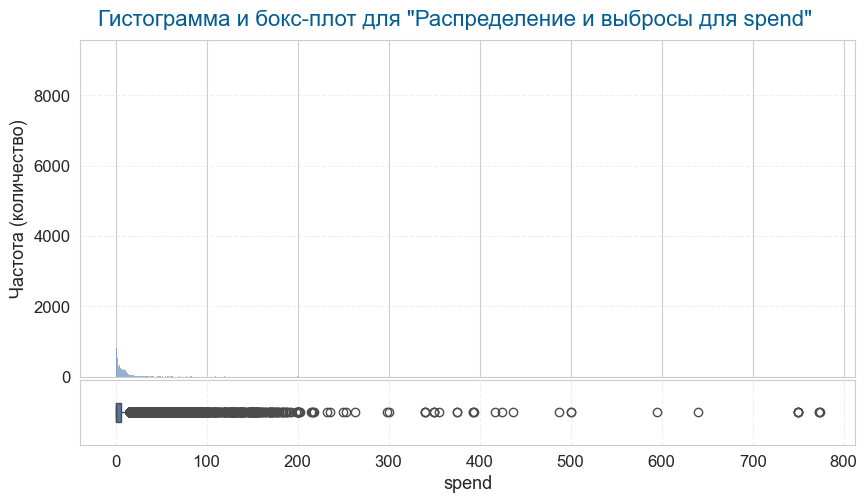


────────────────────────────────────────────────────────────
📌 Описательные статистики для spend:


,0
Название признака,spend
Тип данных,float64
Количество значений,19862
Пропуски (NaN),0
Уникальных значений,2859
Минимум,0.00
Среднее,7.53
Медиана,0.74
Максимум,774.00


────────────────────────────────────────────────────────────
🔍 Определение границ выбросов (метод IQR):


,Слева,Справа
Границы выбросов,-9.24,15.40
Количество выбросов,0.00,1769.00
Процент выбросов,0.00,8.91


In [26]:
col = 'spend' 

if col in df.columns:
    # Красивый заголовок через Markdown
    from IPython.display import display, Markdown
    display(Markdown(f"## 📊 Одномерный анализ: {col.upper()}"))
    print(f"{'='*60}")

    # Визуализация (Гистограмма + Boxplot)
    # Предполагаем, что h.hist_box сам выводит график
    h.hist_box(col, df, title=f"Распределение и выбросы для {col}")
    
    print("\n" + f"{'─'*60}")
    print(f"📌 Описательные статистики для {col}:")
    # Выводим статистику (T - транспонируем для удобства чтения строк)
    display(h.descr_df(df[[col]], show=False).T)

    print(f"{'─'*60}")
    print(f"🔍 Определение границ выбросов (метод IQR):")
    # Вывод границ "усов"
    h.iqr_outliers(col, df)
    
    print(f"{'='*60}\n")
else:
    print(f"⚠️ Столбец {col} не найден в датасете!")

## 📊 Одномерный анализ: CLICKS

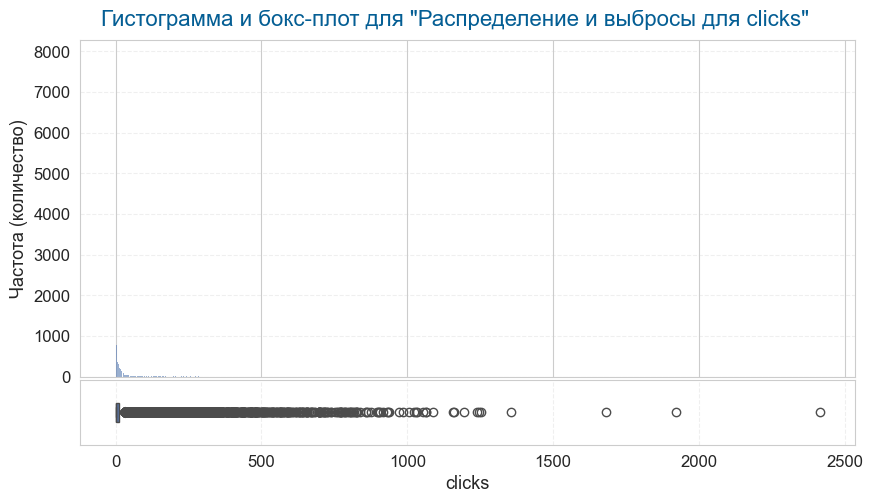


────────────────────────────────────────────────────────────
📌 Описательные статистики для clicks:


,0
Название признака,clicks
Тип данных,int64
Количество значений,19862
Пропуски (NaN),0
Уникальных значений,552
Минимум,0
Среднее,25.10
Медиана,2.00
Максимум,2415


────────────────────────────────────────────────────────────
🔍 Определение границ выбросов (метод IQR):


,Слева,Справа
Границы выбросов,-19.50,32.50
Количество выбросов,0.00,2400.00
Процент выбросов,0.00,12.08


In [27]:
col = 'clicks' 

if col in df.columns:
    # Красивый заголовок через Markdown
    from IPython.display import display, Markdown
    display(Markdown(f"## 📊 Одномерный анализ: {col.upper()}"))
    print(f"{'='*60}")

    # Визуализация (Гистограмма + Boxplot)
    # Предполагаем, что h.hist_box сам выводит график
    h.hist_box(col, df, title=f"Распределение и выбросы для {col}")
    
    print("\n" + f"{'─'*60}")
    print(f"📌 Описательные статистики для {col}:")
    # Выводим статистику (T - транспонируем для удобства чтения строк)
    display(h.descr_df(df[[col]], show=False).T)

    print(f"{'─'*60}")
    print(f"🔍 Определение границ выбросов (метод IQR):")
    # Вывод границ "усов"
    h.iqr_outliers(col, df)
    
    print(f"{'='*60}\n")
else:
    print(f"⚠️ Столбец {col} не найден в датасете!")

## 📊 Одномерный анализ: IMPRESSIONS

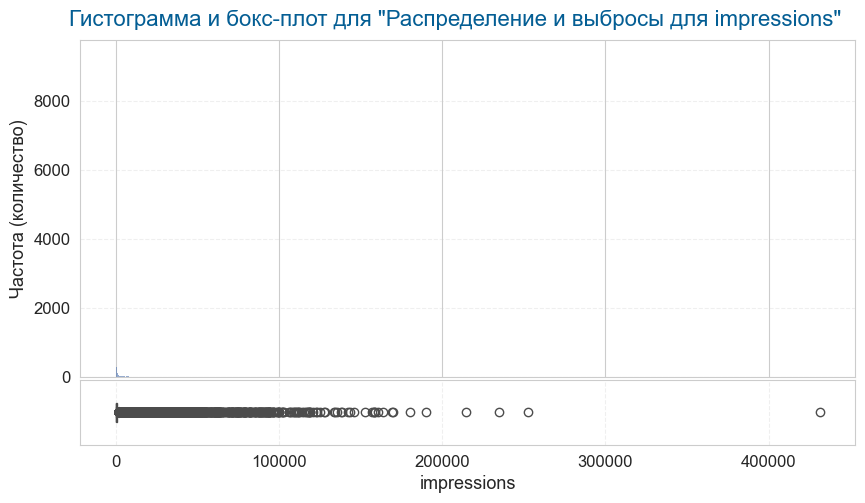


────────────────────────────────────────────────────────────
📌 Описательные статистики для impressions:


,0
Название признака,impressions
Тип данных,int64
Количество значений,19862
Пропуски (NaN),0
Уникальных значений,4003
Минимум,0
Среднее,2571.70
Медиана,82.00
Максимум,431445


────────────────────────────────────────────────────────────
🔍 Определение границ выбросов (метод IQR):


,Слева,Справа
Границы выбросов,-1138.62,1900.38
Количество выбросов,0.00,2633.00
Процент выбросов,0.00,13.26


In [28]:
col = 'impressions' 

if col in df.columns:
    # Красивый заголовок через Markdown
    from IPython.display import display, Markdown
    display(Markdown(f"## 📊 Одномерный анализ: {col.upper()}"))
    print(f"{'='*60}")

    # Визуализация (Гистограмма + Boxplot)
    # Предполагаем, что h.hist_box сам выводит график
    h.hist_box(col, df, title=f"Распределение и выбросы для {col}")
    
    print("\n" + f"{'─'*60}")
    print(f"📌 Описательные статистики для {col}:")
    # Выводим статистику (T - транспонируем для удобства чтения строк)
    display(h.descr_df(df[[col]], show=False).T)

    print(f"{'─'*60}")
    print(f"🔍 Определение границ выбросов (метод IQR):")
    # Вывод границ "усов"
    h.iqr_outliers(col, df)
    
    print(f"{'='*60}\n")
else:
    print(f"⚠️ Столбец {col} не найден в датасете!")

## ⚠️ Наблюдения и решения по выбросам

В ходе анализа метрик `spend`, `clicks` и `impressions` была выявлена сильная **асимметрия данных**. 

### 🔍 Ключевые наблюдения
* **Разрыв между средним и медианой:** Средние значения (например, `spend` = **7.53€**) почти в 10 раз превышают медианные (**0.74€**). Это говорит о том, что основная масса строк в датасете — это мелкие расходы, а общий бюджет формируется за счет небольшого количества крупных кампаний.
* **Границы выбросов (IQR):** Метод «усов» определил как аномалии около **9–13%** данных. Для маркетинга это норма: это наши самые активные и масштабные рекламные объявления.
* **Экстремальные значения:** Мы видим «пики» до **774€** за запись и до **2415** кликов. Эти точки будут максимально влиять на итоговый расчет стоимости лида (CPL).

### ✅ Принятые решения
1. **Отказ от удаления:** Выбросы в маркетинговых данных **не удаляются**. Это реальные затраты бюджета. Их удаление приведет к потере информации о самых масштабных кампаниях и исказит итоговую сумму расходов.
2. **Смена фокуса в анализе:** * При оценке «типичного» объявления будем ориентироваться на **медиану**, а не на среднее, чтобы избежать искажений от единичных всплесков.
    * Для итоговых отчетов будем использовать **агрегированные суммы** (за день/неделю/месяц), что позволит сгладить влияние мелких колебаний.
3. **Визуализация:** При построении графиков в дальнейшем предпочтительно использовать логарифмическую шкалу или ограничивать оси, чтобы детально видеть и массовый сегмент, и лидеров по затратам.


────────────────────────────────────────────────────────────
  Трансформация: impressions_log1p
────────────────────────────────────────────────────────────


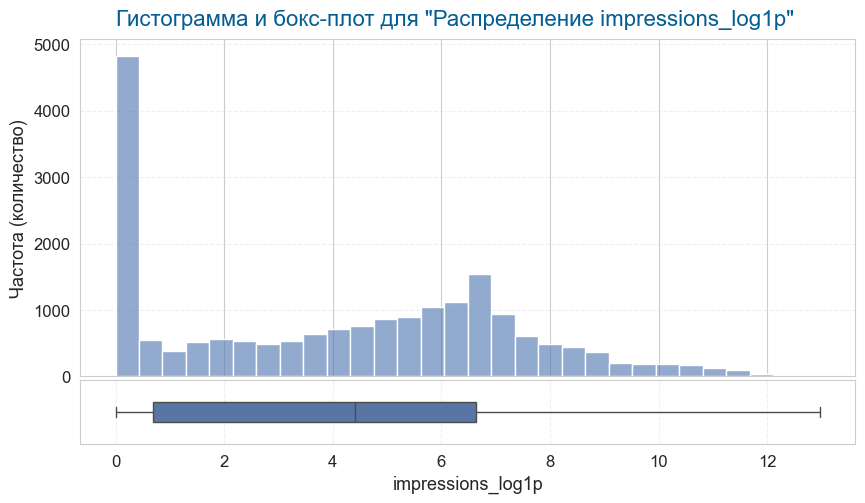

Описательные статистики логарифма:


,0
Название признака,impressions_log1p
Тип данных,float64
Количество значений,19862
Пропуски (NaN),0
Уникальных значений,4003
Минимум,0.00
Среднее,4.08
Медиана,4.42
Максимум,12.97


In [29]:
# Производим логарифмирование и строим визуализации для нового анализа
# Список столбцов с сильной правосторонней асимметрией, которые мы нашли
cols_to_log = ['impressions']

for col in cols_to_log:
    if col in df.columns:
        # 1. Создаем новое имя для колонки
        new_col_name = f"{col}_log1p"
        
        # 2. Применяем логарифмирование (log(1+x))
        df[new_col_name] = np.log1p(df[col])
        
        print(f"\n{'─'*60}")
        print(f"  Трансформация: {new_col_name}")
        print(f"{'─'*60}")
        
        # 3. Строим гистограмму и boxplot для новой колонки
        h.hist_box(new_col_name, df, title=f"Распределение {new_col_name}")
        
        # 4. Выводим новые статистики
        print('Описательные статистики логарифма:')
        display(h.descr_df(df[[new_col_name]], show=False).T)


────────────────────────────────────────────────────────────
  Трансформация: spend_log1p
────────────────────────────────────────────────────────────


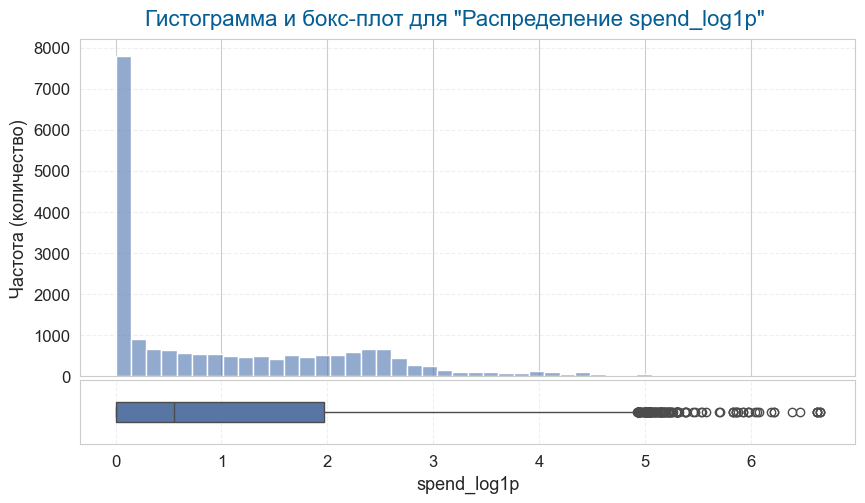

Описательные статистики логарифма:


,0
Название признака,spend_log1p
Тип данных,float64
Количество значений,19862
Пропуски (NaN),0
Уникальных значений,2859
Минимум,0.00
Среднее,1.06
Медиана,0.55
Максимум,6.65


In [30]:
# Производим логарифмирование и строим визуализации для нового анализа
# Список столбцов с сильной правосторонней асимметрией, которые мы нашли
cols_to_log = ['spend']

for col in cols_to_log:
    if col in df.columns:
        # 1. Создаем новое имя для колонки
        new_col_name = f"{col}_log1p"
        
        # 2. Применяем логарифмирование (log(1+x))
        df[new_col_name] = np.log1p(df[col])
        
        print(f"\n{'─'*60}")
        print(f"  Трансформация: {new_col_name}")
        print(f"{'─'*60}")
        
        # 3. Строим гистограмму и boxplot для новой колонки
        h.hist_box(new_col_name, df, title=f"Распределение {new_col_name}")
        
        # 4. Выводим новые статистики
        print('Описательные статистики логарифма:')
        display(h.descr_df(df[[new_col_name]], show=False).T)


────────────────────────────────────────────────────────────
  Трансформация: clicks_log1p
────────────────────────────────────────────────────────────


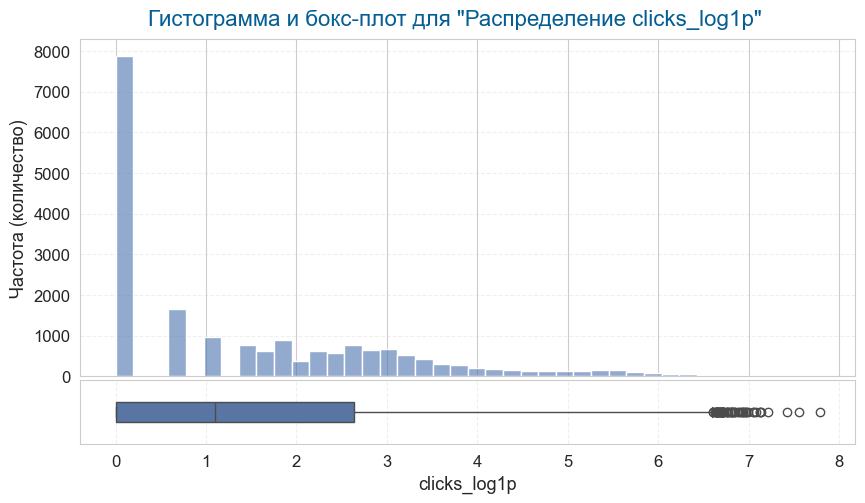

Описательные статистики логарифма:


,0
Название признака,clicks_log1p
Тип данных,float64
Количество значений,19862
Пропуски (NaN),0
Уникальных значений,552
Минимум,0.00
Среднее,1.51
Медиана,1.10
Максимум,7.79


In [31]:
# Производим логарифмирование и строим визуализации для нового анализа
# Список столбцов с сильной правосторонней асимметрией, которые мы нашли
cols_to_log = ['clicks']

for col in cols_to_log:
    if col in df.columns:
        # 1. Создаем новое имя для колонки
        new_col_name = f"{col}_log1p"
        
        # 2. Применяем логарифмирование (log(1+x))
        df[new_col_name] = np.log1p(df[col])
        
        print(f"\n{'─'*60}")
        print(f"  Трансформация: {new_col_name}")
        print(f"{'─'*60}")
        
        # 3. Строим гистограмму и boxplot для новой колонки
        h.hist_box(new_col_name, df, title=f"Распределение {new_col_name}")
        
        # 4. Выводим новые статистики
        print('Описательные статистики логарифма:')
        display(h.descr_df(df[[new_col_name]], show=False).T)

In [32]:
# Обработка выбросов - заполните по решениям из таблицы выше

# Пример: удаление выбросов справа
# col = 'sla'
# outliers = h.iqr_outliers(col, df, show=False)
# right_border = outliers.loc['Границы выбросов', 'Справа']
# df = df[df[col] <= right_border].copy()
# print(f"После удаления выбросов справа в {col}: {df.shape}")

# Пример: удаление выбросов слева
# col = 'initial_amount_paid'
# outliers = h.iqr_outliers(col, df, show=False)
# left_border = outliers.loc['Границы выбросов', 'Слева']
# df = df[df[col] >= left_border].copy()

print(f"Размер датасета после обработки выбросов: {df.shape}")

Размер датасета после обработки выбросов: (19862, 11)


In [33]:
# Удаляем временные логарифмированные признаки перед сохранением cleaned dataset
log_cols = ['impressions_log1p', 'spend_log1p', 'clicks_log1p']
existing_log_cols = [col for col in log_cols if col in df.columns]

if existing_log_cols:
    df = df.drop(columns=existing_log_cols)
    print(f"Удалены временные лог-признаки: {existing_log_cols}")
else:
    print("Временные лог-признаки отсутствуют.")

Удалены временные лог-признаки: ['impressions_log1p', 'spend_log1p', 'clicks_log1p']


**Наблюдения и решения:** 

Логарифмическая трансформация (`log1p`) использовалась как вспомогательный инструмент для визуального анализа распределений. После преобразования асимметрия заметно снижается, и структура данных становится более удобной для интерпретации.

Однако логарифмированные признаки не включаются в финальный cleaned dataset, так как на этапе подготовки данных важно сохранить исходные бизнес-метрики в их реальном масштабе.

---
## 10. Одномерный анализ - категориальные переменные

Для каждой категориальной переменной:
- частотная таблица с долями
- горизонтальный барплот

📊 Анализ: source (14 уникальных значений)


,source,count,%
0,facebook ads,9569,48.20
1,tiktok ads,2985,15.00
2,youtube ads,1784,9.00
3,google ads,1266,6.40
4,telegram posts,836,4.20
5,webinar,766,3.90
6,bloggers,632,3.20
7,smm,571,2.90
8,organic,514,2.60
9,crm,355,1.80


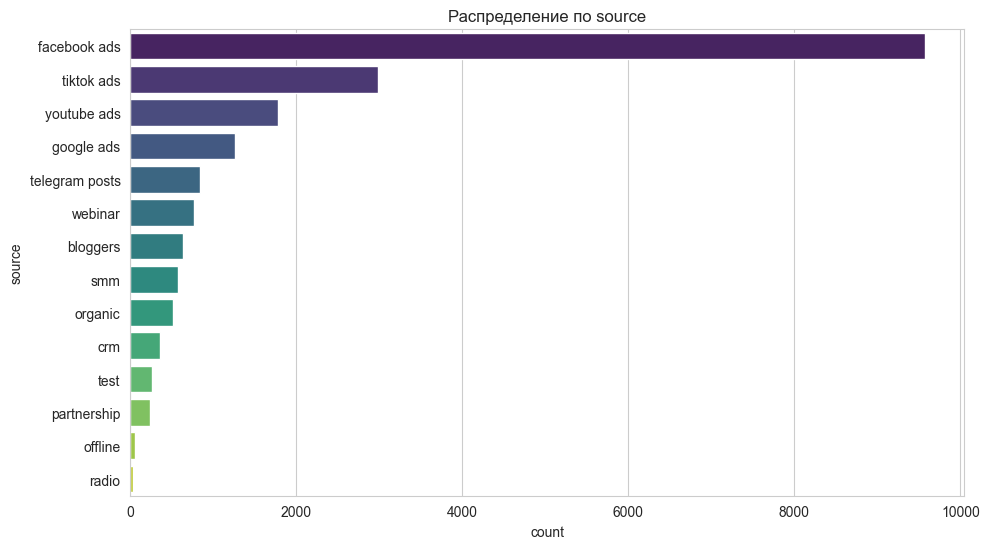

In [34]:
plt_to_save_png = ['source']  

col = 'source' 

if col in df.columns:
    print(f"📊 Анализ: {col} ({df[col].nunique()} уникальных значений)")
    
    # Считаем частоты
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq.head(20)) # Показываем топ-10 в таблице

    # Рисуем график (топ-20)
    top_vals = freq.head(20)
    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', hue=col, palette='viridis', legend=False) 
    
    plt.title(f"Распределение по {col}")
    plt.tight_layout()
    
    # Сохранение (если нужно)
    plt.savefig(IMAGES / f"spend_{col}_barplot.png", dpi=150, bbox_inches='tight')
    plt.show()

### 📂 Наблюдения по источникам (Source)

1. **Доминирование Facebook:** Почти половина всех данных (**48.2%**) приходится на `facebook ads`. Источник является ключевым драйвером трафика в текущем датасете.
2. **Концентрация трафика:** Основной объем работы (более **70%**) сосредоточен в трех каналах: Facebook, TikTok и YouTube. Остальные 11 источников можно считать вспомогательными.
3. **Микро-каналы:** Источники `radio`, `offline` и `partnership` имеют минимальное присутствие (суммарно менее 2%). При глубоком анализе их можно объединять в категорию "Прочие", чтобы не перегружать отчеты.
4. **Чистота данных:** Поле `source` заполнено на 100%, что позволяет нам точно распределить бюджет по верхнеуровневым каналам без потерь.

📊 Анализ: campaign (52 уникальных значений)


,campaign,count,%
0,unknown,5077,25.60
1,12.07.2023wide_de,2073,10.40
2,02.07.23wide_de,1685,8.50
3,04.07.23recentlymoved_de,1398,7.00
4,youtube_shorts_de,1223,6.20
5,07.07.23lal_de,1181,5.90
6,03.07.23women,1171,5.90
7,12.09.23interests_uxui_de,1143,5.80
8,15.07.23b_de,529,2.70
9,24.09.23retargeting_de,504,2.50


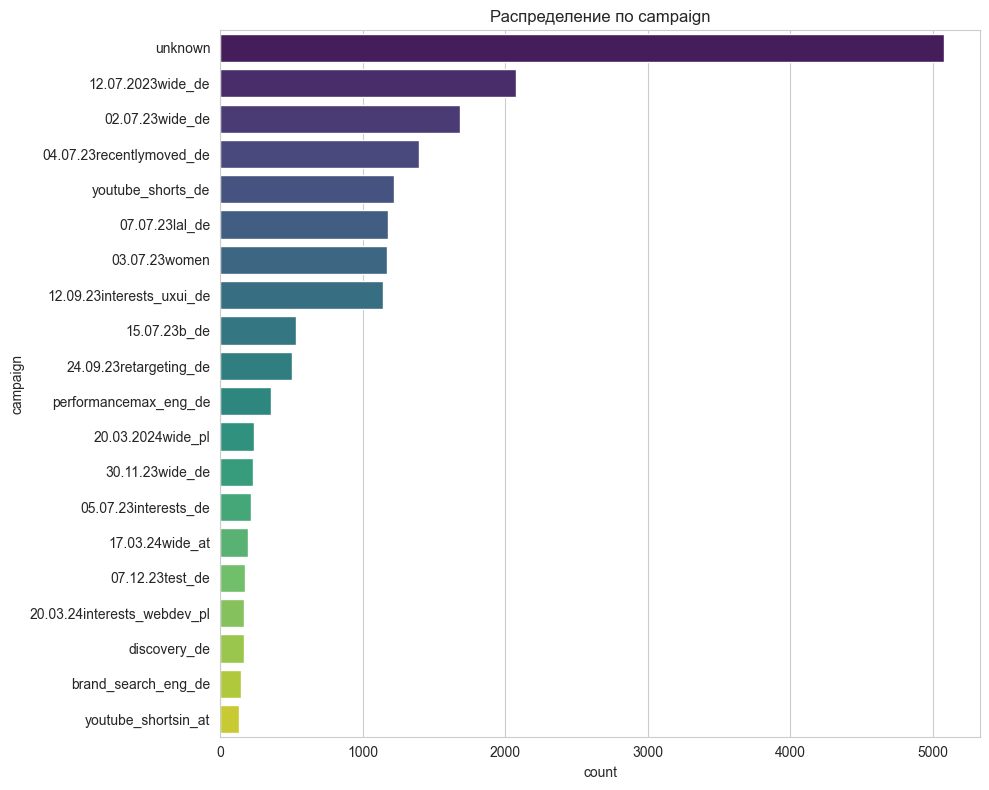

In [35]:
plt_to_save_png = ['campaign']  # Укажите название переменной график которой нужно сохранить

col = 'campaign' # В следующей ячейке поменяешь на 'campaign' и т.д.

if col in df.columns:
    print(f"📊 Анализ: {col} ({df[col].nunique()} уникальных значений)")
    
    # Считаем частоты
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq.head(20)) # Показываем топ-10 в таблице

    # Рисуем график (топ-20)
    top_vals = freq.head(20)
    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', hue=col, palette='viridis', legend=False) 
    
    plt.title(f"Распределение по {col}")
    plt.tight_layout()
    
    # Сохранение (если нужно)
    plt.savefig(IMAGES / f"spend_{col}_barplot.png", dpi=150, bbox_inches='tight')
    plt.show()

### 📂 Наблюдения по кампаниям (Campaign)

1. **Проблема разметки:** Категория `Unknown` занимает первое место (**25.6%**). Это критический объем данных, который требует внимания. Благодаря замене `NaN -> Unknown`, эти данные не потеряны и будут участвовать в расчете общего ROI, но они снижают точность детализированных отчетов.
2. **Лидеры среди размеченных кампаний:** Самой активной является `12.07.2023wide_de` (**10.4%**). В целом, кампаниям с широким таргетингом (`wide`) на немецком рынке уделяется приоритетное внимание.
3. **Региональный охват:** В нейминге четко прослеживается ориентация на регион DACH (Германия, Австрия) с небольшим вкраплением рынка Польши.
4. **Структура кампаний:** Набор включает в себя как охватные инструменты (YouTube Shorts, Performance Max), так и классический ретаргетинг, что говорит о комплексном подходе к маркетингу.

📊 Анализ: adgroup (25 уникальных значений)


,adgroup,count,%
0,unknown,5911,29.80
1,wide,5451,27.40
2,recentlymoved,1442,7.30
3,women,1274,6.40
4,lal1,1220,6.10
5,com_august,1073,5.40
6,interest_work_webdev,733,3.70
7,interest_programming_webdev,636,3.20
8,b,566,2.80
9,retargeting,504,2.50


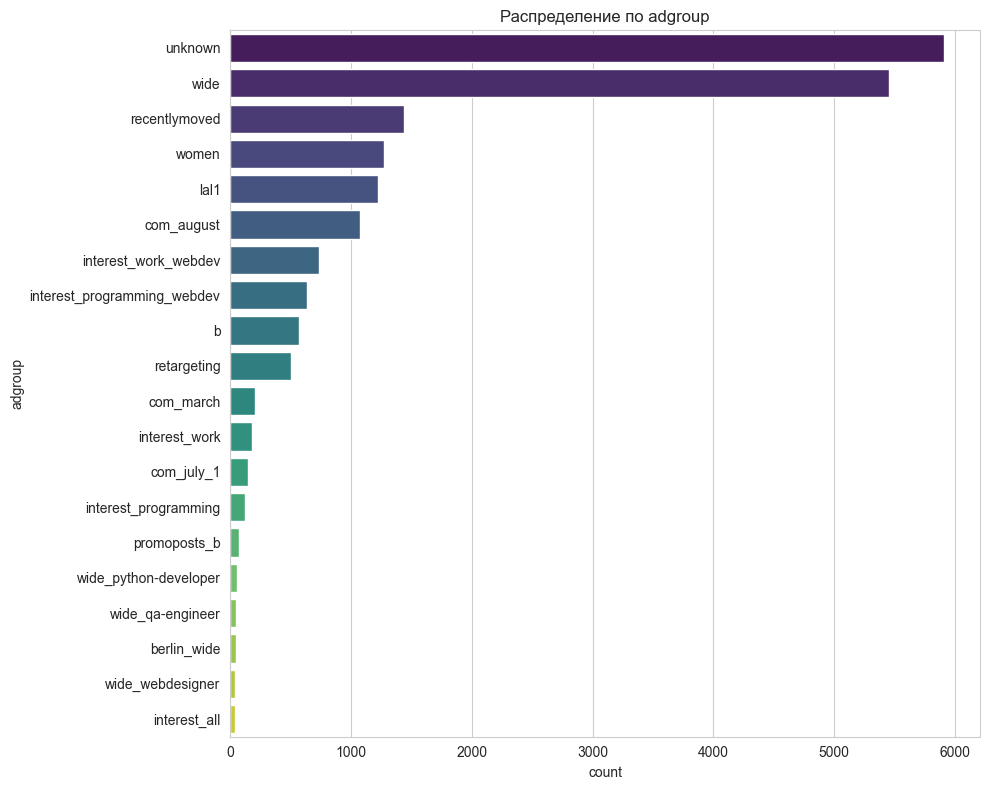

In [36]:
plt_to_save_png = ['adgroup']  

col = 'adgroup' 

if col in df.columns:
    print(f"📊 Анализ: {col} ({df[col].nunique()} уникальных значений)")
    
    # Считаем частоты
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq.head(20)) # Показываем топ-10 в таблице

    # Рисуем график (топ-20)
    top_vals = freq.head(20)
    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', hue=col, palette='viridis', legend=False) 
    
    plt.title(f"Распределение по {col}")
    plt.tight_layout()
    
    # Сохранение (если нужно)
    plt.savefig(IMAGES / f"spend_{col}_barplot.png", dpi=150, bbox_inches='tight')
    plt.show()

### 📂 Наблюдения по группам объявлений (Adgroup)

1. **Рост доли неразмеченных данных:** В этом разрезе категория `Unknown` достигает почти **30%**. Это подтверждает системную проблему с передачей названий групп из рекламных кабинетов в общую базу.
2. **Приоритет широкого охвата:** Группа `wide` лидирует среди размеченных сегментов. Это указывает на доверие к автоматическим алгоритмам оптимизации рекламных площадок.
3. **Профессиональный таргетинг:** Четко выделены IT-направления (Web-dev, Python, QA), что позволяет в дальнейшем оценить эффективность привлечения конкретных специалистов.
4. **Работа с базой:** Относительно небольшая доля ретаргетинга и LAL-аудиторий (суммарно <10%) свидетельствует о том, что стратегия маркетинга в данный период была сфокусирована на привлечении холодного трафика (верхняя часть воронки).

📊 Анализ: ad (177 уникальных значений)


,ad,count,%
0,unknown,5911,29.80
1,bloggersvideo9com,714,3.60
2,bloggersvideo5,711,3.60
3,bloggersvideo3com,565,2.80
4,bloggersvideo8com,536,2.70
5,bloggersvideo11,502,2.50
6,v11comwebdev,498,2.50
7,bloggersvideo4com,386,1.90
8,v15,330,1.70
9,bloggersvideo14com,287,1.40


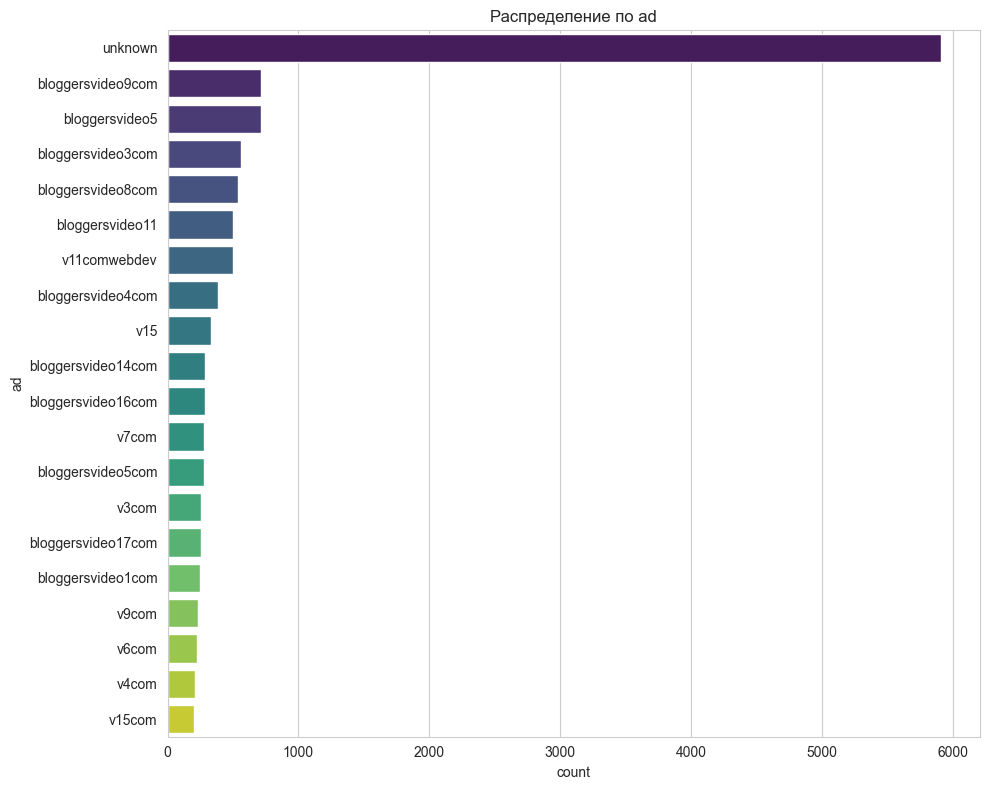

In [37]:
plt_to_save_png = ['ad']  

col = 'ad' 

if col in df.columns:
    print(f"📊 Анализ: {col} ({df[col].nunique()} уникальных значений)")
    
    # Считаем частоты
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, 'count']
    freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
    display(freq.head(20)) # Показываем топ-10 в таблице

    # Рисуем график (топ-20)
    top_vals = freq.head(20)
    plt.figure(figsize=(10, max(3, len(top_vals) * 0.4)))
    sns.barplot(data=top_vals, y=col, x='count', hue=col, palette='viridis', legend=False) 
    
    plt.title(f"Распределение по {col}")
    plt.tight_layout()
    
    # Сохранение (если нужно)
    plt.savefig(IMAGES / f"spend_{col}_barplot.png", dpi=150, bbox_inches='tight')
    plt.show()

### 📂 Наблюдения по объявлениям (Ad)

1. **Подтверждение системных пропусков:** Доля `Unknown` (**29.8%**) идентична показателю по группам объявлений. Это подтверждает, что данные по креативам отсутствуют ровно там же, где потеряна информация о группах.
2. **Фокус на видео-контент:** Среди идентифицированных объявлений преобладают видео-форматы (`bloggersvideo`), что указывает на видео как на основной тип рекламного носителя в этом проекте.
3. **Активное использование итераций:** Наличие множества версий креативов (v1, v3, v9 и т.д.) свидетельствует о системной работе с гипотезами и регулярном проведении A/B тестов.
4. **Высокая гранулярность:** Наличие 177 уникальных объявлений позволяет проводить глубокий анализ эффективности креативов, однако из-за дробления данных такие выводы потребуют более длительных периодов накопления статистики.

📊 Матрица корреляции:


,impressions,spend,clicks
impressions,1.00,0.53,0.88
spend,0.53,1.00,0.59
clicks,0.88,0.59,1.00


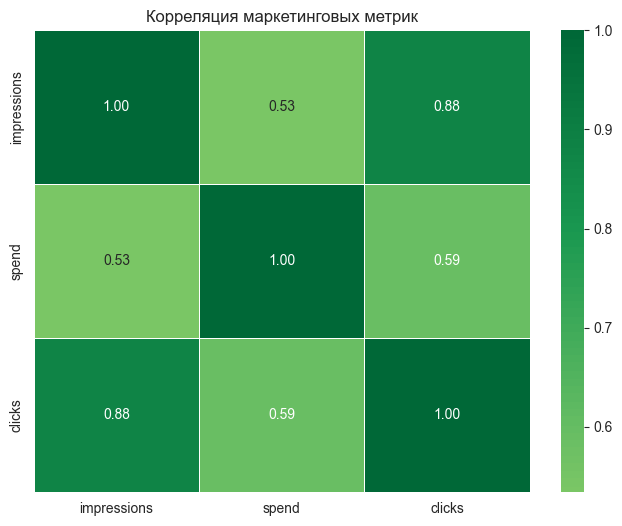

In [38]:
# Выбираем только числовые столбцы для корреляции
num_cols = ['impressions', 'spend', 'clicks']
corr_matrix = df[num_cols].corr()

print("📊 Матрица корреляции:")
display(corr_matrix.round(2))

# Визуализация тепловой карты
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title("Корреляция маркетинговых метрик")
plt.show()

## 📂 Общие наблюдения и решения по категориальным признакам

В ходе анализа структуры текстовых данных (источники, кампании, группы и объявления) были выявлены ключевые закономерности распределения трафика и качества его разметки.

### 🔍 Ключевые наблюдения
* **Доминирование Facebook Ads:** Почти половина всего трафика (**48.2%**) генерируется одним источником. Это делает итоговые показатели проекта сильно зависимыми от эффективности этой площадки.
* **Концентрация трафика:** Топ-3 источника (Facebook, TikTok, YouTube) аккумулируют более **72%** всех записей. Остальные 11 каналов являются вспомогательными и имеют долю менее 5% каждый.
* **Проблемы с глубиной разметки:** * В столбце `campaign` доля неразмеченных данных составляет **25.6%**.
    * В столбцах `adgroup` и `ad` доля «пустот» вырастает до **29.8%**.
    * Это свидетельствует о потере метаданных на уровне объявлений и групп при передаче кликов в базу.
* **Фокус на видео-контент:** Среди идентифицированных объявлений преобладают видео-форматы (`bloggersvideo`) и сложная система версионности креативов (v1, v2, v3...), что говорит об активном проведении A/B тестов.

### ✅ Принятые решения
1. **Сохранение неразмеченного трафика:** Категория `Unknown` оставлена в датасете в полном объеме. Это позволяет сохранить 100% данных о расходах, показах и кликах для корректного расчета общих KPI.
2. **Иерархический подход к анализу:** * Глобальные выводы и расчет эффективности (ROI/CPL) будут проводиться на уровне **Source**, где данные заполнены максимально полно.
    * Детализированный анализ по кампаниям и группам будет применяться только к размеченному сегменту данных (около 70% датасета).
3. **Рекомендация по улучшению:** Для повышения прозрачности аналитики в будущем необходимо внедрить аудит UTM-меток и стандартизировать нейминг во всех рекламных кабинетах.



---
## 11. Одномерный анализ - столбцы с датами

Для каждого датового столбца:
- диапазон и базовая статистика
- распределение по месяцам (временной ряд)

In [39]:
col = 'date'

if col in df.columns:
    print(f"📊 Анализ временных рамок: {col.upper()}")
    print(f"{'─'*60}")
    
    start_date = df[col].min()
    end_date = df[col].max()
    duration = end_date - start_date
    
    print(f"Минимальная дата: {start_date.date()}")
    print(f"Максимальная дата: {end_date.date()}")
    print(f"Общий период:      {duration.days} дней")
    print(f"Уникальных дней:   {df[col].nunique()}")
    print(f"{'─'*60}")

📊 Анализ временных рамок: DATE
────────────────────────────────────────────────────────────
Минимальная дата: 2023-07-03
Максимальная дата: 2024-06-21
Общий период:      354 дней
Уникальных дней:   355
────────────────────────────────────────────────────────────


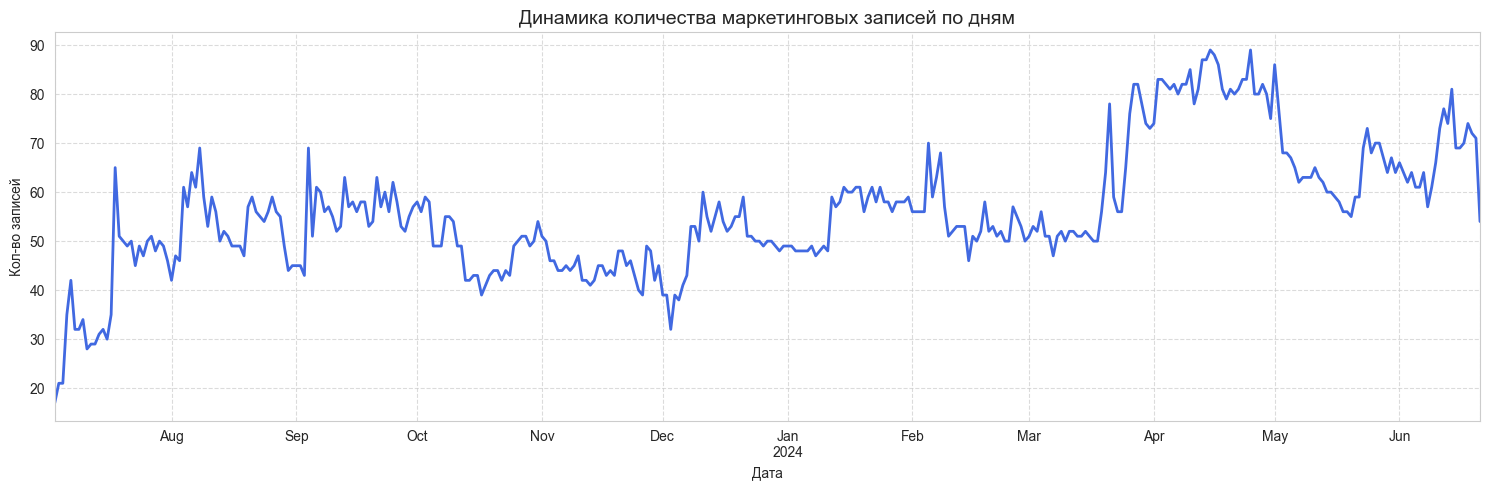

,Месяц,Кол-во записей
0,2023-07,1148
1,2023-08,1666
2,2023-09,1677
3,2023-10,1504
4,2023-11,1342
5,2023-12,1532
6,2024-01,1708
7,2024-02,1583
8,2024-03,1822
9,2024-04,2464


In [40]:
# Группируем данные по дням, чтобы увидеть активность
daily_activity = df.groupby('date').size()

plt.figure(figsize=(15, 5))
daily_activity.plot(kind='line', color='royalblue', linewidth=2)

plt.title('Динамика количества маркетинговых записей по дням', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Кол-во записей')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Группировка по месяцам для таблицы
df['month'] = df['date'].dt.to_period('M')
month_dist = df['month'].value_counts().sort_index().reset_index()
month_dist.columns = ['Месяц', 'Кол-во записей']
display(month_dist)

# Удаляем временный столбец month, чтобы не засорять df
df.drop(columns=['month'], inplace=True)


────────────────────────────────────────────────────────────
📊 АНАЛИЗ ПЕРИОДА: DATE
────────────────────────────────────────────────────────────
  📅 Диапазон:  2023-07-03 — 2024-06-21
  ⏳ Длительность: 354 дней
  🚫 Пропуски:   0


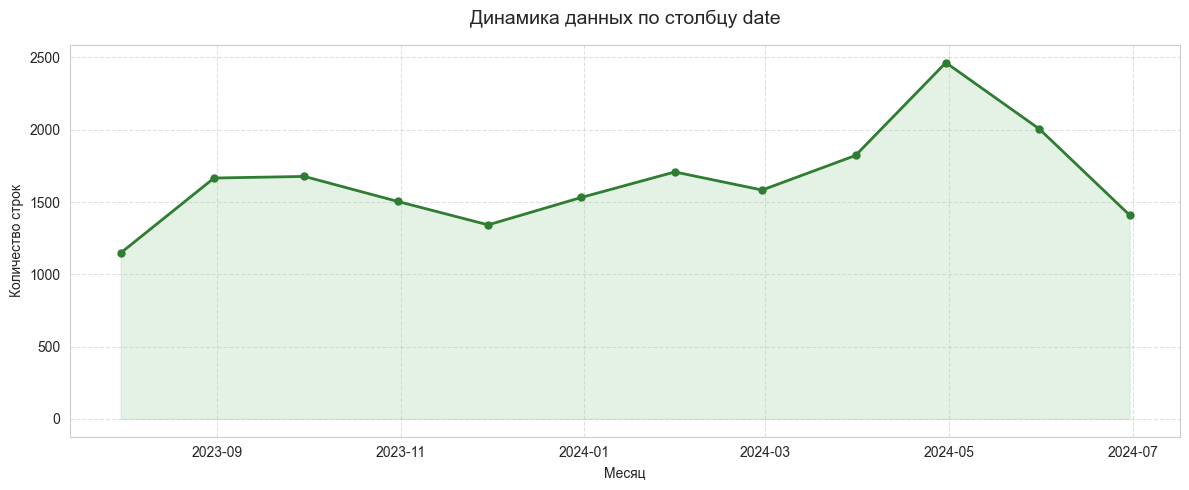

In [41]:
for col in dataset_config['date_cols']:
    if col not in df.columns:
        continue

    print(f"\n{'─'*60}")
    print(f"📊 АНАЛИЗ ПЕРИОДА: {col.upper()}")
    print(f"{'─'*60}")

    # Расширенная статистика
    min_date = df[col].min()
    max_date = df[col].max()
    days_range = (max_date - min_date).days
    
    print(f"  📅 Диапазон:  {min_date.date()} — {max_date.date()}")
    print(f"  ⏳ Длительность: {days_range} дней")
    print(f"  🚫 Пропуски:   {df[col].isnull().sum()}")

    # Временной ряд по месяцам (явно заполняем пропуски нулями)
    monthly = df.set_index(col).resample('ME').size().fillna(0)

    # Визуализация
    plt.figure(figsize=(12, 5))
    plt.plot(monthly.index, monthly.values, 
             marker='o', markersize=5, 
             linewidth=2, color='#2E7D32', # Темно-зеленый цвет
             label='Кол-во записей')
    
    plt.title(f"Динамика данных по столбцу {col}", fontsize=14, pad=15)
    plt.ylabel("Количество строк")
    plt.xlabel("Месяц")
    
    # Добавляем сетку для читаемости
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Заливка области под графиком для красоты
    plt.fill_between(monthly.index, monthly.values, color='#A5D6A7', alpha=0.3)

    plt.tight_layout()
    
    # Сохранение
    plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_timeseries.png", 
                dpi=150, bbox_inches='tight')
    plt.show()

## 📅 Наблюдения и решения по анализу временных рядов

Анализ столбца `date` позволил определить временные границы исследования и оценить стабильность поступления данных.

### 🔍 Ключевые наблюдения

* **Полный годовой цикл:** Данные охватывают период с **3 июля 2023 года** по **21 июня 2024 года** (354 дня). Это позволяет учитывать сезонность и сравнивать показатели разных кварталов.
* **Высокая плотность данных:** У нас 355 уникальных дней на 354 дня периода. Это говорит о том, что данные собирались ежедневно, без технических сбоев и "дырок" в выгрузке.
* **Амплитуда активности:**
    * **Минимум:** Июль 2023 (~1150 записей) — период старта или настройки кампаний.
    * **Пик:** Апрель 2024 (**2464 записи**) — зафиксирован значительный всплеск активности, что может быть связано с весенними промо-акциями или расширением рекламного бюджета.
* **Стабильный фон:** В среднем ежемесячно фиксируется от 1400 до 1800 записей, что обеспечивает достаточную статистическую значимость для анализа.

### ✅ Принятые решения

1. **Целостность данных:** Подтверждено отсутствие пропусков в датах, поэтому дополнительные методы интерполяции (заполнения недостающих дней) не требуются.
2. **Готовность к агрегации:** Имеющийся объем данных позволяет проводить корректный анализ не только по дням, но и в разрезе недель и месяцев для выявления долгосрочных трендов.
3. **Контекст для выводов:** Все будущие показатели (CPL, CTR, ROI) будут рассматриваться с учетом "пикового" апреля, чтобы понять, было ли это масштабирование эффективным или просто увеличило объем "шума".

---
## 12. Одномерный анализ - булевые переменные

Для булевых переменных смотрим на соотношение True / False.

In [42]:
# for col in dataset_config['bool_cols']:
#     if col not in df.columns:
#         print(f"Столбец {col} не найден, пропускаем")
#         continue

#     print(f"\n{'─'*60}")
#     print(f"  {col}")
#     print(f"{'─'*60}")

#     # Частотная таблица
#     freq = df[col].value_counts().reset_index()
#     freq.columns = [col, 'count']
#     freq['%'] = (freq['count'] / freq['count'].sum() * 100).round(1)
#     display(freq)

#     # Пайчарт
#     plt.figure(figsize=(5, 5))
#     plt.pie(freq['count'], labels=freq[col].astype(str),
#             autopct='%1.1f%%', startangle=90)
#     plt.title(f"{col}")
#     plt.tight_layout()
#     # plt.savefig(IMAGES / f"{dataset_config['name']}_{col}_pie.png",
#     #             dpi=150, bbox_inches='tight')
#     plt.show()

**Наблюдения по булевым переменным:**

В датасете булевые признаки отсутствуют. Это ожидаемо, так как таблица рекламных расходов содержит только:
- временное измерение,
- категориальные признаки рекламной структуры,
- числовые маркетинговые метрики.

## !!!Ахтунг!!! 
Нет цели удалить все пропуски в датасете, потому что далее он будет использован только вами

---
## 13. Сохранение

Сохраняем очищенный датасет в `data/processed/` как parquet.  
Если файл с таким именем уже существует - перекладываем его в `data/processed/backup/` с датой и временем.  
Конфиг обновляется в `data/processed/`.

In [43]:
sufix = 'cleaned'

dataset_path = PROCESSED / f"{dataset_config['name']}_{sufix}.xlsx"

# Если файл уже есть - бэкапим его перед перезаписью
if dataset_path.exists():
    timestamp = datetime.now().strftime('%Y%m%d_%H%M')
    backup_path = BACKUP / f"{dataset_config['name']}_{sufix}_{timestamp}.xlsx"
    dataset_path.rename(backup_path)
    print(f"Предыдущий файл -> бэкап: {backup_path.name}")

# Сохраняем очищенный датасет
df.to_excel(dataset_path, index=False)
print(f"Датасет сохранён:  {dataset_path}")
print(f"Размер:            {df.shape[0]} строк × {df.shape[1]} столбцов")

Предыдущий файл -> бэкап: spend_cleaned_20260416_0743.xlsx
Датасет сохранён:  E:\ICH\Python Data analyse\crm\data\processed\spend_cleaned.xlsx
Размер:            19862 строк × 8 столбцов


In [44]:
# Сохраняем обновлённый конфиг
with open(config_path, 'wb') as f:
    pickle.dump(dataset_config, f)

print(f"Конфиг сохранён: {config_path}")
print()
print("Итоговый конфиг:")
for key, val in dataset_config.items():
    print(f"  {key}: {val}")

Конфиг сохранён: E:\ICH\Python Data analyse\crm\data\processed\spend_config.pkl

Итоговый конфиг:
  name: spend
  filename: Spend (Done).xlsx
  num_cols: ['impressions', 'spend', 'clicks']
  cat_cols: ['source', 'campaign', 'adgroup', 'ad']
  date_cols: ['date']
  drop_cols: []


In [45]:
# Проверяем что всё сохранилось
print("Содержимое папки processed/:")
for f in sorted(PROCESSED.glob('*')):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {f.name}  ({size_kb:.1f} KB)")

print()
print("Содержимое папки backup/:")
for f in sorted(BACKUP.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Содержимое папки processed/:
  calls_cleaned.xlsx  (0.0 KB)
  calls_config.pkl  (0.3 KB)
  contacts_cleaned.xlsx  (778.5 KB)
  contacts_config.pkl  (0.2 KB)
  crm_analysis.xlsx  (5522.7 KB)
  deals_cleaned.xlsx  (0.0 KB)
  deals_config.pkl  (0.4 KB)
  FINAL_UE_DATA.csv  (11616.2 KB)
  spend_cleaned.xlsx  (728.6 KB)
  spend_config.pkl  (0.2 KB)

Содержимое папки backup/:
  calls_cleaned_20260331_1907.xlsx  (4714.7 KB)
  calls_cleaned_20260331_2055.xlsx  (4714.7 KB)
  calls_cleaned_20260331_2115.xlsx  (4714.7 KB)
  calls_cleaned_20260402_2208.xlsx  (5509.2 KB)
  calls_cleaned_20260410_0900.xlsx  (5925.0 KB)
  calls_cleaned_20260411_1732.xlsx  (5925.0 KB)
  calls_cleaned_20260411_2144.xlsx  (7882.1 KB)
  calls_cleaned_20260413_1156.xlsx  (7882.1 KB)
  calls_cleaned_20260414_0853.xlsx  (7882.1 KB)
  calls_cleaned_20260414_1211.xlsx  (7882.1 KB)
  calls_cleaned_20260414_1708.xlsx  (7882.1 KB)
  calls_cleaned_20260415_0859.xlsx  (7882.1 KB)
  calls_cleaned_20260416_0743.xlsx  (7882.1 KB)
  c

---
## 14. Зависимости окружения

In [46]:
!pip freeze > "{dataset_config['name']}_requirements.txt"

---
## 15. Итоговые описательные статистики

In [47]:
# можно загрузить из PROCESSED, чтобы убедиться, что сохранили все верно 
dataset_path

WindowsPath('E:/ICH/Python Data analyse/crm/data/processed/spend_cleaned.xlsx')

In [48]:
df.describe(include='all')

,date,source,campaign,impressions,spend,clicks,adgroup,ad
count,19862,19862,19862,19862.00,19862.00,19862.00,19862,19862
unique,NaN,14,52,NaN,NaN,NaN,25,177
top,NaN,facebook ads,unknown,NaN,NaN,NaN,unknown,unknown
freq,NaN,9569,5077,NaN,NaN,NaN,5911,5911
mean,2024-01-10 18:21:55.879568896,NaN,NaN,2571.70,7.53,25.10,NaN,NaN
min,2023-07-03 00:00:00,NaN,NaN,0.00,0.00,0.00,NaN,NaN
25%,2023-10-09 00:00:00,NaN,NaN,1.00,0.00,0.00,NaN,NaN
50%,2024-01-20 00:00:00,NaN,NaN,82.00,0.74,2.00,NaN,NaN
75%,2024-04-12 00:00:00,NaN,NaN,760.75,6.16,13.00,NaN,NaN
max,2024-06-21 00:00:00,NaN,NaN,431445.00,774.00,2415.00,NaN,NaN


In [49]:
# Сводная таблица по числовым столбцам 
h.descr_df(df)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Минимум,Среднее,Медиана,Максимум
0,impressions,int64,19862,0,4003,0.00,2571.70,82.00,431445.00
1,spend,float64,19862,0,2859,0.00,7.53,0.74,774.00
2,clicks,int64,19862,0,552,0.00,25.10,2.00,2415.00


In [50]:
# Создаем расширенную статистику
stats = df[dataset_config['num_cols']].describe().T

# Добавляем Range (Размах)
stats['range'] = stats['max'] - stats['min']

# Добавляем IQR (Межквартильный размах)
stats['iqr'] = stats['75%'] - stats['25%']

# Переименовываем для красоты и округляем
stats.columns = ['Count', 'Mean', 'Std', 'Min', '25%', 'Median', '75%', 'Max', 'Range', 'IQR']
display(stats.round(2))

,Count,Mean,Std,Min,25%,Median,75%,Max,Range,IQR
impressions,19862.00,2571.70,11691.23,0.00,1.00,82.00,760.75,431445.00,431445.00,759.75
spend,19862.00,7.53,27.33,0.00,0.00,0.74,6.16,774.00,774.00,6.16
clicks,19862.00,25.10,87.03,0.00,0.00,2.00,13.00,2415.00,2415.00,13.00


In [51]:
# Сводная таблица по datetime столбцам 
h.descr_df(df, include=['datetime'], show_stats=True, show_sample_rows=True)

,Название признака,Тип данных,Количество значений,Пропуски (NaN),Уникальных значений,Пример строка 1,Пример строка 2,Пример строка 3
0,date,datetime64[ns],19862,0,355,2023-07-03,2023-07-03,2023-07-03


# 🏁 Финальные выводы по результатам одномерного анализа (EDA)

На текущем этапе завершена очистка и первичный статистический анализ датасета **Spend**. Данные подготовлены к расчету ключевых бизнес-метрик и объединению с таблицей конверсий.

---

### 1. 📊 Технический статус датасета
* **Объем:** 19 862 записи.
* **Качество:** Пропуски отсутствуют (**Non-Null Count = 100%**). Типы данных оптимизированы: `date` (datetime64), `spend` (float64), `clicks/impressions` (int64).
* **Период анализа:** С **3 июля 2023** по **21 июня 2024** (354 дня). Данные поступали непрерывно, без технических разрывов в выгрузке.

### 2. 🔍 Ключевые аналитические инсайты

#### 📈 Асимметрия и "Длинный хвост"
Числовые метрики демонстрируют экстремальный разброс. **Средние значения в разы превышают медиану**:
* **Spend:** Среднее **7.53€** при медиане всего **0.74€**. Размах (**Range**) достигает **774€**.
* **Инсайт:** Основная часть рекламных объявлений (75% согласно **IQR**) требует минимальных затрат (до 6.16€). Общий бюджет формируется за счет небольшого количества высокобюджетных кампаний-лидеров.

#### 🌍 Структура источников и разметки
* **Доминирование Facebook:** Источник `facebook ads` генерирует почти половину всех записей (**48.2%**). Проект сильно зависит от эффективности данной площадки.
* **Проблема "Unknown" разметки:** * В поле `source` пропусков нет.
    * В полях `campaign`, `adgroup` и `ad` доля неразмеченных данных составляет от **25.6% до 29.8%**. 
* **Решение:** Категория `Unknown` сохранена для корректного учета 100% затрат, однако глубокая аналитика креативов будет проводиться только на размеченном сегменте.

#### 🎥 Контентная стратегия
Среди идентифицированных объявлений преобладают видео-форматы (`bloggersvideo`), что в сочетании с множеством версий (v1, v2, v3...) указывает на активное использование **A/B тестирования** и работу с инфлюенс-маркетингом.

### 💡 Итоговое решение
Данные признаны **репрезентативными и качественными**. Экстремальные значения (выбросы) сохранены, так как являются реальными бизнес-показателями. Датасет готов к агрегации и расчету метрик эффективности (CPL, ROMI).